# LSTM — Weekend Gap Prediction

**Role in the project:** Sequential model for temporal pattern detection. Logistic regression and XGBoost treat each Monday row as an independent observation — they cannot see whether RSI has been rising for three consecutive weeks, or whether volume has been building. LSTM (Long Short-Term Memory) is designed specifically to learn from sequences: it processes 4 consecutive weekly observations per ticker and decides what information to carry forward and what to forget.

**Key differences from LogReg and XGBoost:**
- **Input:** sequences of 4 weeks, not single rows
- **Temporal structure:** the model can learn that momentum over N weeks predicts the gap direction
- **Rolling 3-year training window:** only the 3 most recent years before the test year are used for training. Discards stale market regimes and prevents older data from poisoning later folds.
- **No fundamentals:** quarterly metrics repeat across 13 consecutive weekly rows — the LSTM gate mechanism has nothing temporal to learn from a flat dimension
- **Preprocessing required:** LSTM gates use sigmoid/tanh activations, sensitive to feature scale

**Configuration chosen via systematic experiment:** 6 variants were tested across window size (4 vs 8 weeks) and training strategy (expanding vs rolling 3yr/4yr). Short window + rolling 3yr achieved the best average AUC (0.5614) across non-COVID folds.

**The research question LSTM answers:** Is there sequential, week-over-week signal in technical features that static models cannot detect?

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             precision_score, recall_score,
                             confusion_matrix, roc_curve)

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  device: {DEVICE}')

PyTorch 2.7.0  |  device: cpu


## 1. Load Data & Define Feature Set

In [129]:
df_all  = pd.read_csv('../structured_csv_data_files/fetched_data/dataset_clean.csv',
                      parse_dates=['Date'])

primary = df_all[df_all['is_extreme_event'] == 0].copy().reset_index(drop=True)
extreme = df_all[df_all['is_extreme_event'] == 1].copy().reset_index(drop=True)

gap_primary = primary['GapUp'].mean()
gap_extreme = extreme['GapUp'].mean()
print(f'Primary dataset: {len(primary):,} rows   GapUp rate: {gap_primary:.3f}')
print(f'Extreme events:  {len(extreme):,} rows   GapUp rate: {gap_extreme:.3f}')

Primary dataset: 8,146 rows   GapUp rate: 0.516
Extreme events:  291 rows   GapUp rate: 0.450


In [130]:
# LSTM uses 14 technical features — fundamentals are excluded.
#
# Why no fundamentals:
#   GrossMargin, NetMargin, RoA, RevGrowthQoQ are reported quarterly.
#   In the dataset, each fundamental value is repeated across ~13 consecutive
#   weekly rows within the same quarter. Feeding a flat dimension (same value
#   for 8 consecutive timesteps) gives the LSTM gate mechanism nothing temporal
#   to learn. The LSTM would be forced to treat it as a static bias — which is
#   exactly what LogReg and XGBoost already do, with no benefit from sequencing.
#
# Missingness indicators excluded: encode data quality, not market dynamics.
# 4 leaky price aggregates still excluded (same as all models).

MOMENTUM   = ['RSI', 'MACD', 'ROC', 'StochPercK']
TREND      = ['CloseVEma50', 'CloseVSma20', 'ADX']
VOLATILITY = ['BollingerBandWidth', 'ATR', 'FiveDStdDev']
VOLUME     = ['OBV', 'MFI', 'VolumeRatio']
PRICE_AGG  = ['WeeklyRange']

FEATURES = MOMENTUM + TREND + VOLATILITY + VOLUME + PRICE_AGG
TARGET   = 'GapUp'
WINDOW   = 4   # 4-week lookback window (chosen via variant experiment)

print(f'Feature count:    {len(FEATURES)}')
print(f'Sequence window:  {WINDOW} weeks')
for grp, feats in [('Momentum', MOMENTUM), ('Trend', TREND), ('Volatility', VOLATILITY),
                   ('Volume', VOLUME), ('Price Agg', PRICE_AGG)]:
    print(f'  {grp:12s}: {feats}')

missing = [f for f in FEATURES if f not in primary.columns]
print(f'\nMissing columns: {missing if missing else "None — all 14 present"}')

Feature count:    14
Sequence window:  4 weeks
  Momentum    : ['RSI', 'MACD', 'ROC', 'StochPercK']
  Trend       : ['CloseVEma50', 'CloseVSma20', 'ADX']
  Volatility  : ['BollingerBandWidth', 'ATR', 'FiveDStdDev']
  Volume      : ['OBV', 'MFI', 'VolumeRatio']
  Price Agg   : ['WeeklyRange']

Missing columns: None — all 14 present


## 2. Preprocessing — Required for LSTM

Unlike XGBoost, LSTM is sensitive to feature scale. The LSTM cell uses sigmoid and tanh activation functions internally — large input values saturate these functions, killing gradient flow during backpropagation (the vanishing gradient problem at the input level).

**Approach:** `StandardScaler` fitted on the training window only, applied to validation and test. The scaler is fitted on all training timesteps (not just the first row of each sequence) to capture the full distribution of each feature.

**OBV note:** OBV is cumulative and not cross-ticker comparable. StandardScaler within each fold's training data effectively z-scores it; the per-ticker OBV range will vary but the scaler captures the aggregate training distribution. This is sufficient since sequences are per-ticker and the model sees relative OBV dynamics within each sequence.

## 3. Sequence Construction — 4-Week Sliding Window

Each sequence pairs 4 consecutive weekly rows (the input) with the GapUp label of the 4th (most recent) row as the target. Sequences are built per-ticker to prevent cross-ticker contamination.

A 4-week window was selected over 8 weeks through systematic comparison: shorter windows generalise better across market regimes because they focus on near-term momentum rather than medium-term patterns that may not repeat in a different year.

The target week's year determines which fold split a sequence belongs to — this ensures temporal integrity across the walk-forward folds.

In [131]:
def build_sequences(df, features, target, window=8):
    """
    Builds per-ticker sliding window sequences.

    For each ticker, iterates chronologically. Each sequence of length `window`
    uses rows [i-window+1 .. i] as input and the label of row i as target.
    The year of row i (the target week) determines fold membership.

    Returns
    -------
    X       : (N, window, n_features)  float32
    y       : (N,)                     float32 binary label
    years   : (N,)                     int     year of target week
    extreme : (N,)                     int     1 if target row is extreme event
    """
    X_list, y_list, yr_list, ex_list = [], [], [], []
    has_extreme = 'is_extreme_event' in df.columns

    for ticker, grp in df.sort_values(['Ticker', 'Date']).groupby('Ticker'):
        grp        = grp.reset_index(drop=True)
        feat_vals  = grp[features].values.astype(np.float32)
        tgt_vals   = grp[target].values.astype(np.float32)
        yr_vals    = grp['Year'].values
        ex_vals    = grp['is_extreme_event'].values if has_extreme else np.zeros(len(grp), dtype=int)

        for i in range(window - 1, len(grp)):
            X_list.append(feat_vals[i - window + 1 : i + 1])
            y_list.append(tgt_vals[i])
            yr_list.append(yr_vals[i])
            ex_list.append(ex_vals[i])

    return (np.array(X_list, dtype=np.float32),
            np.array(y_list,  dtype=np.float32),
            np.array(yr_list),
            np.array(ex_list))


# Build sequences once from primary (non-COVID) rows.
# Filter by target year during fold construction.
X_all, y_all, years_all, _ = build_sequences(primary, FEATURES, TARGET, WINDOW)

print(f'Total sequences:  {len(X_all):,}')
print(f'Sequence shape:   {X_all.shape}  (N, window, features)')
gap_rate = y_all.mean()
print(f'GapUp rate:       {gap_rate:.3f}')
print()
print('Sequences per year:')
for yr in sorted(np.unique(years_all)):
    n = (years_all == yr).sum()
    print(f'  {yr}: {n:,}')

Total sequences:  8,071
Sequence shape:   (8071, 4, 14)  (N, window, features)
GapUp rate:       0.517

Sequences per year:
  2016: 662
  2017: 979
  2018: 966
  2019: 992
  2020: 613
  2021: 917
  2022: 997
  2023: 953
  2024: 992


## 4. LSTM Architecture

A single-layer LSTM with a linear output head.

| Component | Detail | Rationale |
|-----------|--------|-----------|
| LSTM layer | 1 layer, hidden_size tuned | Single layer avoids vanishing gradients with small datasets (~3k–7k sequences) |
| Last timestep | `out[:, -1, :]` | The final hidden state encodes all sequence history via the LSTM's memory |
| Dropout | After LSTM, before linear | Regularization; prevents overfitting to training sequences |
| Linear + Sigmoid | Maps hidden → [0,1] | Probability of GapUp |
| Loss | BCELoss | Standard for binary classification |
| Optimizer | Adam (lr=0.001) | Adaptive learning rate, robust default for LSTM |

In [132]:
class LSTMGapPredictor(nn.Module):
    """
    Single-layer LSTM for binary weekend gap prediction.
    Input:  (batch, seq_len=8, input_size=14)
    Output: (batch,) — sigmoid probability of GapUp
    """
    def __init__(self, input_size, hidden_size, dropout=0.2):
        super().__init__()
        self.lstm    = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                               num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)          # (batch, seq_len, hidden)
        out    = out[:, -1, :]         # last timestep: (batch, hidden)
        out    = self.dropout(out)
        return torch.sigmoid(self.fc(out)).squeeze(-1)  # (batch,)

In [133]:
def make_loader(X, y, batch_size=64, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        proba = model(torch.tensor(X, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    preds = (proba >= 0.5).astype(int)
    return roc_auc_score(y, proba), accuracy_score(y, preds), proba


def fit_model(X_train, y_train, X_val, y_val,
              hidden_size, dropout, lr=0.001,
              max_epochs=50, patience=10, batch_size=64):
    model     = LSTMGapPredictor(X_train.shape[2], hidden_size, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    loader    = make_loader(X_train, y_train, batch_size=batch_size)
    best_auc, best_state, wait = -np.inf, None, 0
    for _ in range(max_epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()
        val_auc, _, _ = evaluate(model, X_val, y_val)
        if val_auc > best_auc + 1e-4:
            best_auc, best_state, wait = val_auc, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    return model, best_auc


def run_walkforward(X_all, label='', transform=None):
    """Rolling walk-forward CV. Returns (results_df, fold_results, fold_models,
    fold_Xts, fold_yts, fold_proba, fold_params)."""
    sc = RobustScaler()
    fold_results, fold_models, fold_Xts, fold_yts, fold_probas, fold_params = [], [], [], [], [], []

    for fold in FOLDS:
        test_yr, train_yrs = fold['test_year'], fold['train_years']
        iv_yr  = max(train_yrs)
        it_yrs = [y for y in train_yrs if y != iv_yr]

        mi = np.isin(years_all, it_yrs);  vi = years_all == iv_yr
        mf = np.isin(years_all, train_yrs); mt = years_all == test_yr

        nf = X_all.shape[2]
        sc.fit(X_all[mf].reshape(-1, nf))

        def prep(X):
            s = sc.transform(X.reshape(-1, nf)).reshape(X.shape).astype(np.float32)
            return transform(s) if transform else s

        Xi, yi = prep(X_all[mi]), y_all[mi]
        Xv, yv = prep(X_all[vi]), y_all[vi]
        Xf, yf = prep(X_all[mf]), y_all[mf]
        Xt, yt = prep(X_all[mt]), y_all[mt]

        best_auc, best_p = -np.inf, None
        for p in PARAM_GRID:
            torch.manual_seed(42)
            _, va = fit_model(Xi, yi, Xv, yv, **p)
            if va > best_auc:
                best_auc, best_p = va, p.copy()

        torch.manual_seed(42)
        model, _ = fit_model(Xf, yf, Xv, yv, **best_p)
        auc, acc, proba = evaluate(model, Xt, yt)
        preds = (proba >= 0.5).astype(int)

        fold_results.append({
            'Test year': test_yr,
            'AUC-ROC':   round(auc, 4), 'Accuracy':  round(acc, 4),
            'Precision': round(precision_score(yt, preds, zero_division=0), 4),
            'Recall':    round(recall_score(yt, preds,    zero_division=0), 4),
            'F1':        round(f1_score(yt, preds,        zero_division=0), 4),
            'Baseline':  round(max(yt.mean(), 1 - yt.mean()), 4),
        })
        fold_models.append(model); fold_Xts.append(Xt)
        fold_yts.append(yt);       fold_probas.append(proba)
        fold_params.append(best_p)
        if label:
            print(f'  [{label}] {test_yr} | h={best_p["hidden_size"]} dr={best_p["dropout"]} | AUC={auc:.3f}')

    return (pd.DataFrame(fold_results).set_index('Test year'),
            fold_results, fold_models, fold_Xts, fold_yts, fold_probas, fold_params)

## 5. Walk-Forward Validation & Hyperparameter Tuning

**Rolling 3-year training window** — only the 3 most recent years before the test year are used for training, rather than all available history (expanding window). This prevents older market regimes (e.g., 2016–2018 pre-AI-era dynamics) from dominating the training set in later folds.

| Test year | Training years | Rationale |
|-----------|---------------|-----------|
| 2019 | 2016–2018 | Same as expanding (only 3 years available) |
| 2020 | 2017–2019 | Drops 2016 |
| 2021 | 2018–2020 | Drops 2016–2017 |
| 2022 | 2019–2021 | Drops 2016–2018 |
| 2023 | 2020–2022 | Drops 2016–2019 |
| 2024 | 2021–2023 | Drops 2016–2020 |

**LSTM hyperparameters tuned:**

| Parameter | What it controls | Grid |
|-----------|-----------------|------|
| `hidden_size` | Capacity of the LSTM memory. | 32, 64 |
| `dropout` | Fraction of hidden units zeroed after LSTM output. | 0.2, 0.3 |

Learning rate fixed at 0.001. Number of layers fixed at 1.

**Inner validation:** last calendar year of each training window is carved off for hyperparameter selection. Best configuration is then refit on the full 3-year training window.

In [134]:
FOLDS = [
    {'train_years': [2016, 2017, 2018], 'test_year': 2019},
    {'train_years': [2017, 2018, 2019], 'test_year': 2020},
    {'train_years': [2018, 2019, 2020], 'test_year': 2021},
    {'train_years': [2019, 2020, 2021], 'test_year': 2022},
    {'train_years': [2020, 2021, 2022], 'test_year': 2023},
    {'train_years': [2021, 2022, 2023], 'test_year': 2024},
]

PARAM_GRID = [
    {'hidden_size': h, 'dropout': d}
    for h in [32, 64]
    for d in [0.2, 0.3]
]

print(f'Training strategy: rolling 3-year window')
print(f'Hyperparameter combinations: {len(PARAM_GRID)}')
print()
for fold in FOLDS:
    n_train = np.isin(years_all, fold['train_years']).sum()
    n_test  = (years_all == fold['test_year']).sum()
    yr_range = f"{fold['train_years'][0]}-{fold['train_years'][-1]}"
    print(f"  Train {yr_range} ({n_train:,} seqs) → Test {fold['test_year']} ({n_test:,} seqs)")

Training strategy: rolling 3-year window
Hyperparameter combinations: 4

  Train 2016-2018 (2,607 seqs) → Test 2019 (992 seqs)
  Train 2017-2019 (2,937 seqs) → Test 2020 (613 seqs)
  Train 2018-2020 (2,571 seqs) → Test 2021 (917 seqs)
  Train 2019-2021 (2,522 seqs) → Test 2022 (997 seqs)
  Train 2020-2022 (2,527 seqs) → Test 2023 (953 seqs)
  Train 2021-2023 (2,867 seqs) → Test 2024 (992 seqs)


In [135]:
print('Original LSTM — 14 features:')
(results_df, fold_results,
 fold_models, fold_Xts, fold_y_test,
 fold_proba, fold_best_params) = run_walkforward(X_all, 'Original')

Original LSTM — 14 features:
  [Original] 2019 | h=32 dr=0.2 | AUC=0.548
  [Original] 2020 | h=64 dr=0.3 | AUC=0.527
  [Original] 2021 | h=64 dr=0.3 | AUC=0.528


KeyboardInterrupt: 

## 6. Walk-Forward Results

In [ ]:
results_df = pd.DataFrame(fold_results).set_index('Test year')

display(results_df.style
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
             'F1': '{:.4f}', 'AUC-ROC': '{:.4f}', 'Baseline': '{:.4f}'})
    .highlight_between(subset=pd.IndexSlice[[2020], :], color='#fff3cd'))

non_covid = results_df[results_df.index != 2020]
print(f'Average metrics (excluding COVID fold):')
print(f'  Accuracy:  {non_covid["Accuracy"].mean():.4f}')
print(f'  Precision: {non_covid["Precision"].mean():.4f}')
print(f'  Recall:    {non_covid["Recall"].mean():.4f}')
print(f'  F1:        {non_covid["F1"].mean():.4f}')
print(f'  AUC-ROC:   {non_covid["AUC-ROC"].mean():.4f}')
print(f'  Baseline:  {non_covid["Baseline"].mean():.4f}')

,AUC-ROC,Accuracy,Precision,Recall,F1,Baseline
Test year,,,,,,
2019,0.5478,0.5454,0.5589,0.6456,0.5991,0.5262
2020,0.5265,0.5318,0.6073,0.4827,0.5378,0.5644
2021,0.5276,0.5104,0.5230,0.5308,0.5269,0.5136
2022,0.5612,0.5065,0.4409,0.7348,0.5511,0.5878
2023,0.5465,0.5289,0.5155,0.6052,0.5568,0.5110
2024,0.5570,0.5333,0.6259,0.4595,0.5299,0.5726


Average metrics (excluding COVID fold):
  Accuracy:  0.5249
  Precision: 0.5328
  Recall:    0.5952
  F1:        0.5528
  AUC-ROC:   0.5480
  Baseline:  0.5422


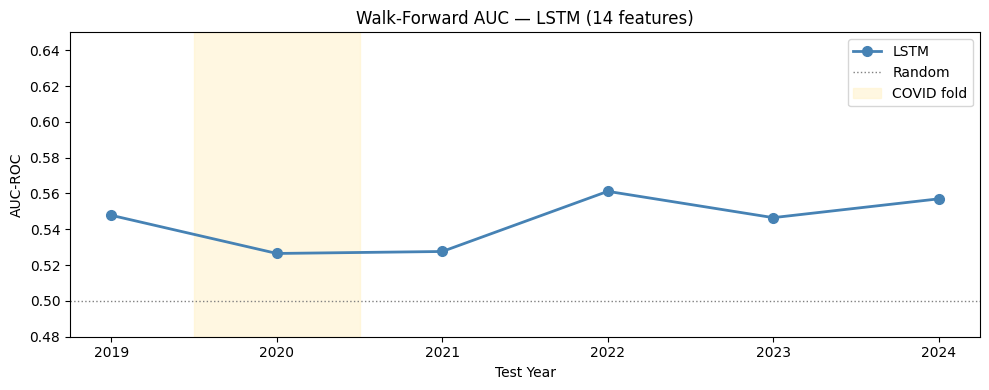

In [ ]:
# AUC-ROC evolution over walk-forward folds.

test_years = results_df.index.tolist()
lstm_auc   = results_df['AUC-ROC'].tolist()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test_years, lstm_auc, 'o-', color='steelblue', lw=2, ms=7, label='LSTM')
ax.axhline(0.5, color='grey', ls=':', lw=1, label='Random')
ax.axvspan(2019.5, 2020.5, color='#fff3cd', alpha=0.6, label='COVID fold')
ax.set_xlabel('Test Year'); ax.set_ylabel('AUC-ROC')
ax.set_title('Walk-Forward AUC — LSTM (14 features)')
ax.legend(); ax.set_ylim(0.48, 0.65)
plt.tight_layout(); plt.show()

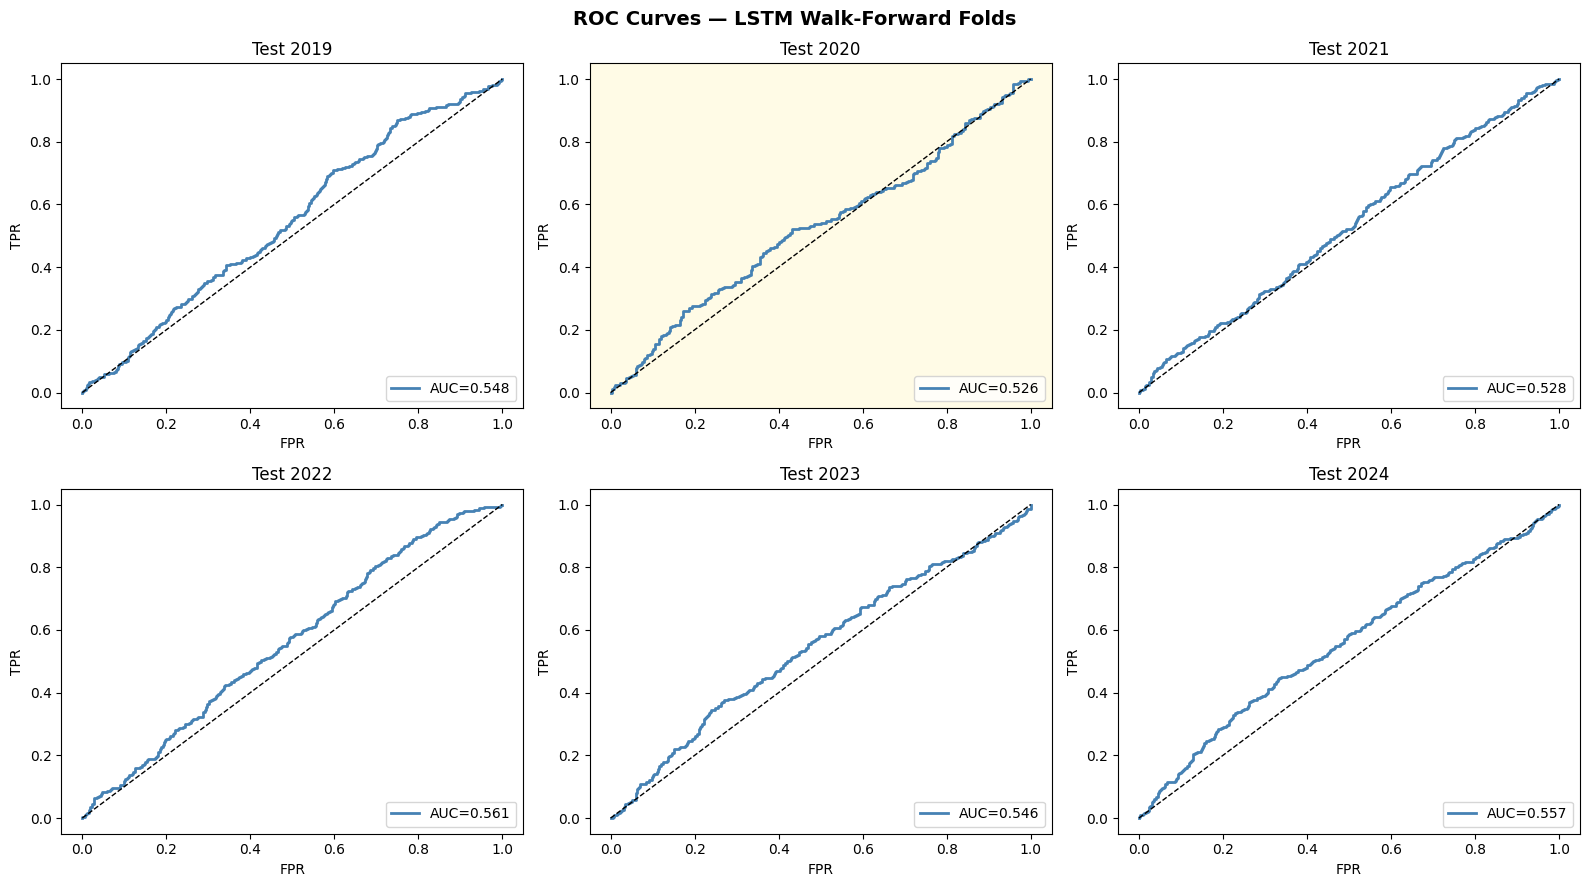

In [ ]:
# ROC curves per fold.

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (proba, y_test, row) in enumerate(zip(fold_proba, fold_y_test,
                                              fold_results)):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val      = row['AUC-ROC']
    ax = axes[i]
    ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC={auc_val:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(f'Test {row["Test year"]}', fontsize=12)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right')
    if row['Test year'] == 2020:
        ax.set_facecolor('#fffbe6')

fig.suptitle('ROC Curves — LSTM Walk-Forward Folds', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

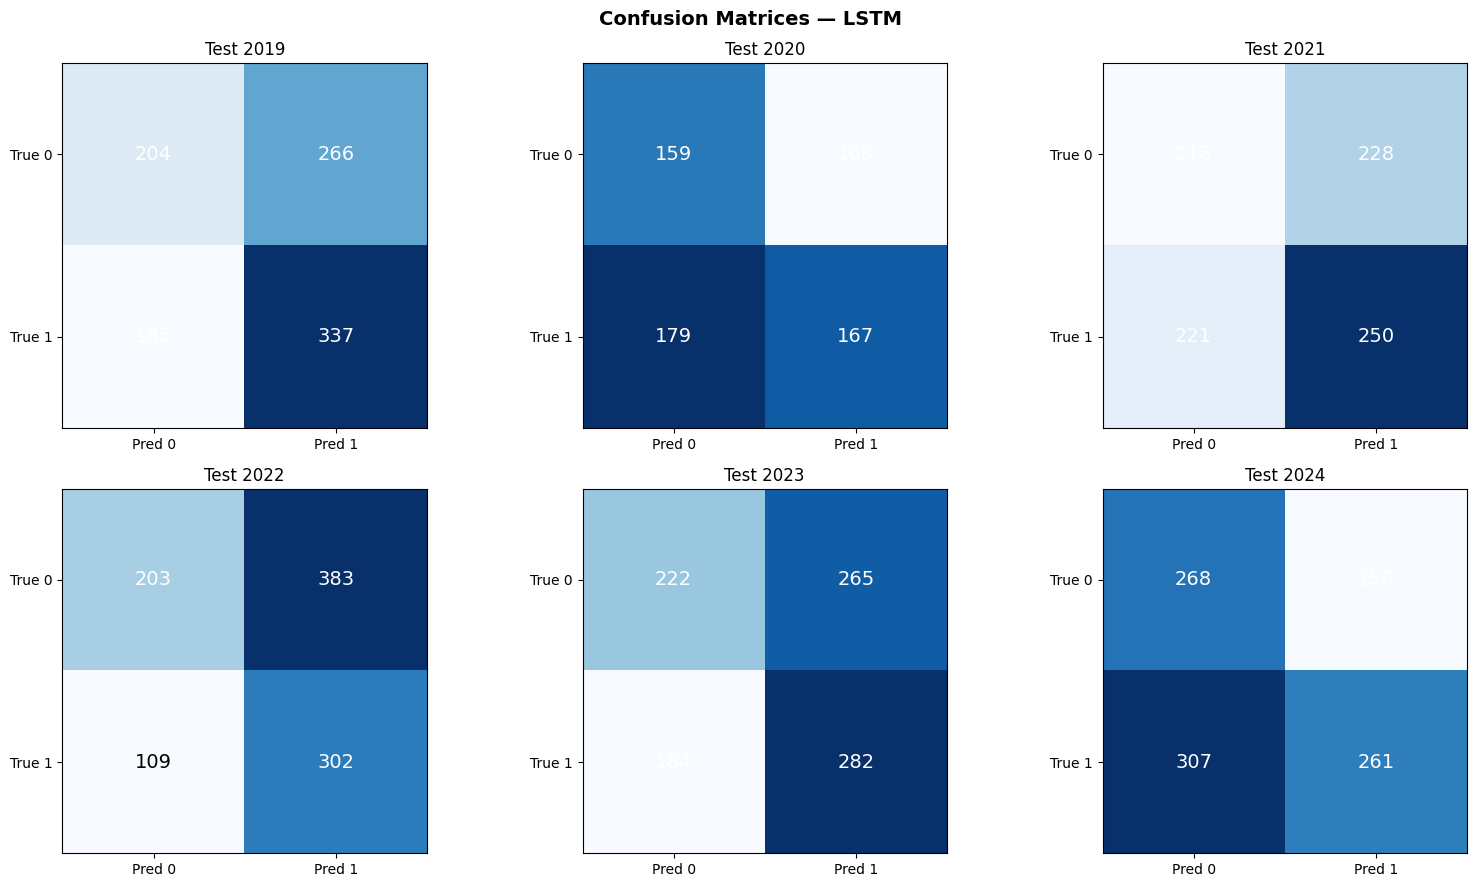

In [ ]:
# Confusion matrices per fold.

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (proba, y_test, row) in enumerate(zip(fold_proba, fold_y_test, fold_results)):
    preds = (proba >= 0.5).astype(int)
    cm    = confusion_matrix(y_test, preds)
    ax    = axes[i]
    im    = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred 0', 'Pred 1'])
    ax.set_yticklabels(['True 0', 'True 1'])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha='center', va='center', fontsize=14,
                    color='white' if cm[r, c] > cm.max() / 2 else 'black')
    ax.set_title(f'Test {row["Test year"]}', fontsize=12)

fig.suptitle('Confusion Matrices — LSTM', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 7. Permutation Feature Importance

For each feature, all values at that feature index are randomly shuffled across sequences (breaking the relationship between that feature and the target), and the AUC drop is measured. Averaged over 5 shuffles per feature per fold.

- **Positive drop:** shuffling hurts the model — the feature carries real signal in the temporal sequence
- **Near zero / negative:** the feature does not contribute to LSTM's predictions

This is more informative than LSTM weight magnitudes, which do not directly indicate feature contribution.

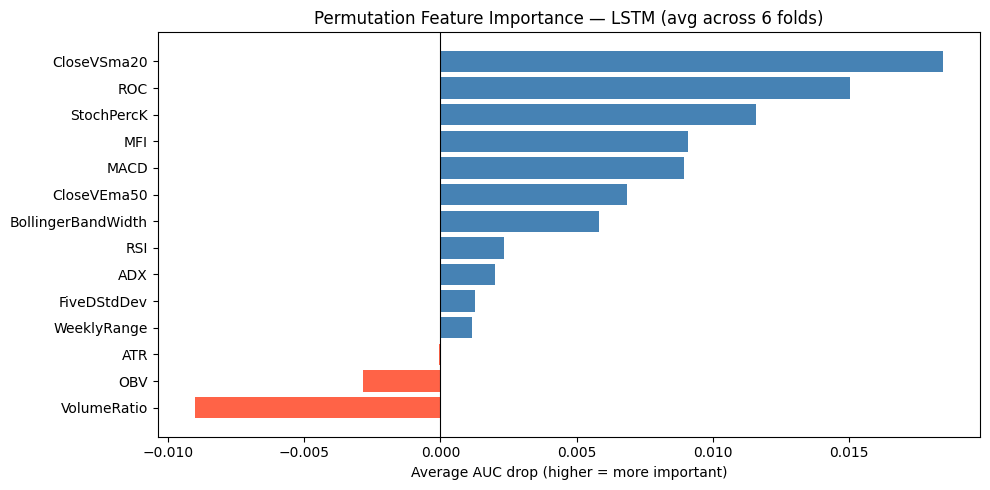

CloseVSma20           0.01843
ROC                   0.01502
StochPercK            0.01160
MFI                   0.00907
MACD                  0.00894
CloseVEma50           0.00684
BollingerBandWidth    0.00583
RSI                   0.00234
ADX                   0.00199
FiveDStdDev           0.00126
WeeklyRange           0.00115
ATR                  -0.00004
OBV                  -0.00284
VolumeRatio          -0.00900


In [ ]:
fold_importances = []
for model, Xt, yt, row in zip(fold_models, fold_Xts, fold_y_test, fold_results):
    base_auc = row['AUC-ROC']
    perm_imp = {}
    for fi, feat in enumerate(FEATURES):
        drops = []
        for _ in range(5):
            Xp = Xt.copy()
            Xp[:, :, fi] = Xp[np.random.permutation(Xp.shape[0]), :, fi]
            drops.append(evaluate(model, Xp, yt)[0])
        perm_imp[feat] = round(base_auc - np.mean(drops), 5)
    fold_importances.append(perm_imp)

imp_df = pd.DataFrame(fold_importances).T
imp_df.columns = [f['test_year'] for f in FOLDS]
imp_df['Avg AUC drop'] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values('Avg AUC drop', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if v >= 0 else 'tomato' for v in imp_df['Avg AUC drop']]
ax.barh(imp_df.index, imp_df['Avg AUC drop'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Average AUC drop (higher = more important)')
ax.set_title('Permutation Feature Importance — LSTM (avg across 6 folds)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print(imp_df['Avg AUC drop'].round(5).to_string())

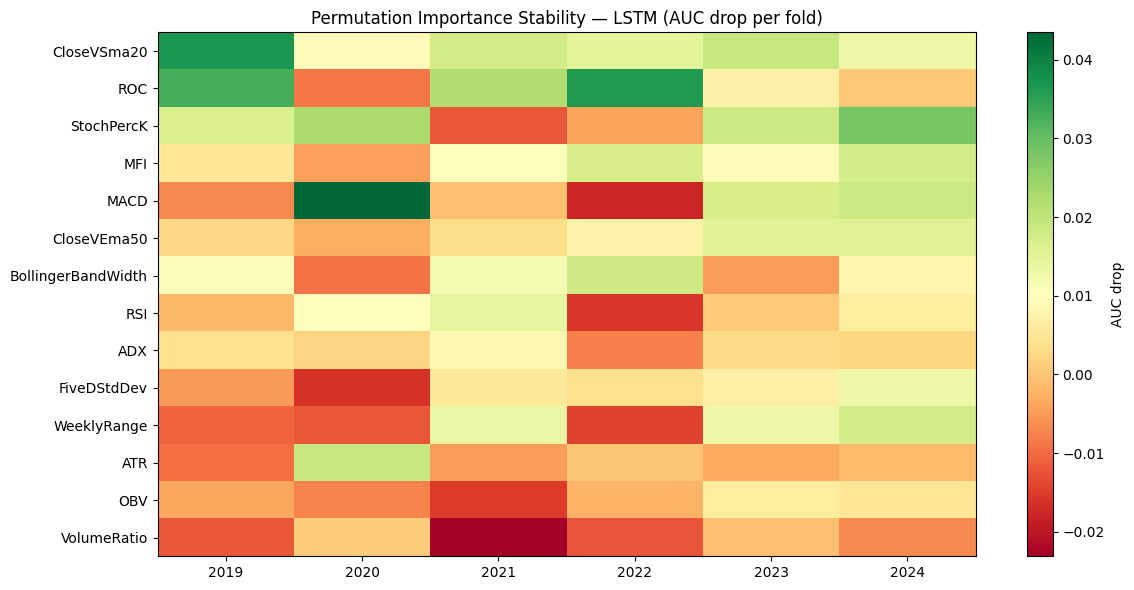

In [ ]:
# Stability heatmap: importance per fold.
# Features that are consistently important across folds are robust signals.
# Features with high variance across folds may be fold-specific noise.

heatmap_data = imp_df.drop(columns='Avg AUC drop').astype(float)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
plt.colorbar(im, ax=ax, label='AUC drop')
ax.set_title('Permutation Importance Stability — LSTM (AUC drop per fold)')
plt.tight_layout(); plt.show()

In [ ]:
# LSTM permutation importance ranks (AUC drop).

lstm_rank = imp_df['Avg AUC drop'].rank(ascending=False).astype(int).rename('LSTM rank')
importance_table = pd.DataFrame({'Avg AUC drop': imp_df['Avg AUC drop'], 'Rank': lstm_rank})
importance_table = importance_table.sort_values('Rank')

print('Feature ranking by LSTM permutation importance (AUC drop):')
print(importance_table.round(5).to_string())

Feature ranking by LSTM permutation importance (AUC drop):
                    Avg AUC drop  Rank
CloseVSma20              0.01843     1
ROC                      0.01502     2
StochPercK               0.01160     3
MFI                      0.00907     4
MACD                     0.00894     5
CloseVEma50              0.00684     6
BollingerBandWidth       0.00583     7
RSI                      0.00234     8
ADX                      0.00199     9
FiveDStdDev              0.00126    10
WeeklyRange              0.00115    11
ATR                     -0.00004    12
OBV                     -0.00284    13
VolumeRatio             -0.00900    14


## 8. Hyperparameter Analysis

In [ ]:
params_df = pd.DataFrame(fold_best_params, index=[f['test_year'] for f in FOLDS])
params_df.index.name = 'Test year'
print('Best hyperparameters per fold:')
display(params_df)

Best hyperparameters per fold:


,hidden_size,dropout
Test year,,
2019,32,0.2
2020,64,0.3
2021,64,0.3
2022,32,0.2
2023,32,0.3
2024,64,0.2


## 10. Secondary Evaluation — COVID Extreme Events

Same setup as LogReg and XGBoost secondary evaluations:
- Train on 2016–2019 (pre-COVID)
- Test on 291 COVID extreme event rows (Feb–May 2020)

For LSTM, sequences targeting COVID weeks draw their lookback from Dec 2019–Jan 2020 (all pre-COVID), so there is no data leakage. The COVID test sequences are built from `df_all` to include the extreme event rows as targets.

In [ ]:
# Build sequences from the full dataset (primary + extreme) to get COVID target sequences.
# The extreme flag identifies which sequences have an extreme event as the target week.

X_full2, y_full2, years_full2, extreme_flags = build_sequences(
    df_all, FEATURES, TARGET, WINDOW)

# Pre-COVID training: non-extreme sequences from 2016-2019
mask_pre = (extreme_flags == 0) & (years_full2 < 2020)
X_pre_c, y_pre_c = X_full2[mask_pre], y_full2[mask_pre]

# COVID test: sequences whose target week is an extreme event
mask_cov = (extreme_flags == 1)
X_cov_c,  y_cov_c  = X_full2[mask_cov], y_full2[mask_cov]

# Inner val for early stopping: 2019 non-extreme sequences
mask_val_c = (extreme_flags == 0) & (years_full2 == 2019)
X_val_c, y_val_c = X_full2[mask_val_c], y_full2[mask_val_c]

# Scale: fit on pre-COVID training
n_feat = X_pre_c.shape[2]
scaler.fit(X_pre_c.reshape(-1, n_feat))

def sc2(X):
    return scaler.transform(X.reshape(-1, n_feat)).reshape(X.shape).astype(np.float32)

X_pre_s = sc2(X_pre_c)
X_val_s = sc2(X_val_c)
X_cov_s = sc2(X_cov_c)

# Use best params from fold 2 (which tested on 2020)
covid_params = fold_best_params[1]
torch.manual_seed(42)
covid_model, _ = fit_model(X_pre_s, y_pre_c, X_val_s, y_val_c, **covid_params)

cov_auc, cov_acc, cov_proba = evaluate(covid_model, X_cov_s, y_cov_c)
cov_preds    = (cov_proba >= 0.5).astype(int)
cov_baseline = max(y_cov_c.mean(), 1 - y_cov_c.mean())

print('Secondary evaluation — COVID extreme event rows (Feb-May 2020):')
print(f'  Metric          LSTM        XGBoost     LogReg')
print(f'  {"---":40s}')
print(f'  Accuracy         {cov_acc:.4f}      0.6392      —')
print(f'  Precision        {precision_score(y_cov_c, cov_preds, zero_division=0):.4f}      0.5625      —')
print(f'  Recall           {recall_score(y_cov_c, cov_preds, zero_division=0):.4f}      0.8931      —')
print(f'  F1               {f1_score(y_cov_c, cov_preds, zero_division=0):.4f}      0.6903      —')
print(f'  AUC-ROC          {cov_auc:.4f}      0.7243      0.7810')
print(f'  Baseline         {cov_baseline:.4f}      0.5498      —')
print()
print('Reminder: elevated COVID AUC across all models is an artifact of the')
print('crash being directionally unidirectional, not evidence of robustness.')

Secondary evaluation — COVID extreme event rows (Feb-May 2020):
  Metric          LSTM        XGBoost     LogReg
  ---                                     
  Accuracy         0.5704      0.6392      —
  Precision        0.5205      0.5625      —
  Recall           0.5802      0.8931      —
  F1               0.5487      0.6903      —
  AUC-ROC          0.5816      0.7243      0.7810
  Baseline         0.5498      0.5498      —

Reminder: elevated COVID AUC across all models is an artifact of the
crash being directionally unidirectional, not evidence of robustness.


## 11. Summary

In [ ]:
lstm_avg_auc = non_covid['AUC-ROC'].mean()
lstm_avg_acc = non_covid['Accuracy'].mean()
lstm_avg_f1  = non_covid['F1'].mean()

mode_hidden = params_df['hidden_size'].mode()[0]
mode_drop   = params_df['dropout'].mode()[0]

top5 = imp_df['Avg AUC drop'].head(5)

print('=' * 65)
print('LSTM — RESULTS SUMMARY')
print('=' * 65)
print(f'Model:       LSTM (single layer, last-timestep output)')
print(f'Features:    {len(FEATURES)} technical (no fundamentals)')
print(f'Window:      {WINDOW} weeks')
print(f'Scaling:     RobustScaler (fit on training sequences only)')
print(f'Validation:  Rolling walk-forward, 6 folds (2019-2024)')
print()
print('Most common hyperparameters selected:')
print(f'  hidden_size : {mode_hidden}')
print(f'  dropout     : {mode_drop}')
print()
print('Primary evaluation (excluding COVID fold):')
print(f'  Avg Accuracy:  {lstm_avg_acc:.4f}')
print(f'  Avg F1:        {lstm_avg_f1:.4f}')
print(f'  Avg AUC-ROC:   {lstm_avg_auc:.4f}')
print(f'  Avg Baseline:  {non_covid["Baseline"].mean():.4f}')
print()
print('Top 5 features by permutation importance (avg AUC drop):')
for feat, drop in top5.items():
    print(f'  {feat:25s}  drop={drop:.5f}')
print()
print('COVID secondary AUC:')
print(f'  LSTM: {cov_auc:.4f}')
print('=' * 65)

LSTM — RESULTS SUMMARY
Model:       LSTM (single layer, last-timestep output)
Features:    14 technical (no fundamentals)
Window:      4 weeks
Scaling:     RobustScaler (fit on training sequences only)
Validation:  Rolling walk-forward, 6 folds (2019-2024)

Most common hyperparameters selected:
  hidden_size : 32
  dropout     : 0.2

Primary evaluation (excluding COVID fold):
  Avg Accuracy:  0.5249
  Avg F1:        0.5528
  Avg AUC-ROC:   0.5480
  Avg Baseline:  0.5422

Top 5 features by permutation importance (avg AUC drop):
  CloseVSma20                drop=0.01843
  ROC                        drop=0.01502
  StochPercK                 drop=0.01159
  MFI                        drop=0.00907
  MACD                       drop=0.00894

COVID secondary AUC:
  LSTM: 0.5816


## 12. Durbin-Watson Autocorrelation Analysis

**Motivation for Durbin-Watson feature selection:**  
LSTM is specifically designed to exploit sequential dependencies. A feature that exhibits strong autocorrelation — where the value at time t is predictable from t−1, t−2, etc. — provides the LSTM with a learnable temporal signal. A feature that is white noise offers no sequential advantage over static models.

The **Durbin-Watson (DW) statistic** tests for first-order autocorrelation in a series:
- DW ≈ 2.0 → no autocorrelation (white noise — little temporal signal for LSTM)
- DW < 2.0 → positive autocorrelation (persistent trends — LSTM can exploit)
- DW > 2.0 → negative autocorrelation (mean-reverting — may still be exploitable)

**Approach:**
1. Compute DW per feature per ticker (features are time series per ticker)
2. Aggregate by mean DW across all tickers
3. Select features with mean DW significantly far from 2.0 (|DW − 2| > 0.3)
4. Rerun LSTM with the selected feature subset and compare results

In [ ]:
from statsmodels.stats.stattools import durbin_watson

primary_sorted = primary.sort_values('Date').reset_index(drop=True)
dw_vals = {feat: durbin_watson(primary_sorted[feat].ffill().bfill().values)
           for feat in FEATURES}

dw_summary = pd.DataFrame({
    'DW':      pd.Series(dw_vals),
    '|DW-2|':  (pd.Series(dw_vals) - 2).abs(),
}).sort_values('|DW-2|', ascending=False)

print('DW ≈ 2 = no autocorr  |  DW < 2 = positive (persistent)  |  DW > 2 = negative (mean-reverting)')
print()
print(dw_summary.round(4).to_string())

DW ≈ 2 = no autocorr  |  DW < 2 = positive (persistent)  |  DW > 2 = negative (mean-reverting)

                        DW  |DW-2|
OBV                -0.7356  2.7356
ADX                 0.2360  1.7640
MFI                 0.2772  1.7228
RSI                 0.2786  1.7214
StochPercK          0.2958  1.7042
WeeklyRange         0.3465  1.6535
BollingerBandWidth  0.4095  1.5905
FiveDStdDev         0.4524  1.5476
VolumeRatio         0.4772  1.5228
ATR                 0.9911  1.0089
CloseVEma50         1.2209  0.7791
CloseVSma20         1.2804  0.7196
ROC                 1.2830  0.7170
MACD                1.6046  0.3954


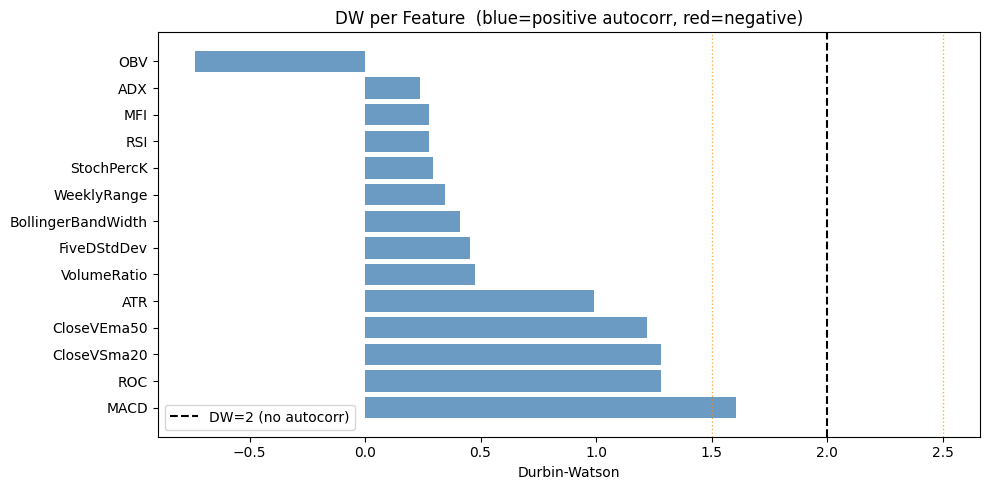

DW selected 14/14: ['OBV', 'ADX', 'MFI', 'RSI', 'StochPercK', 'WeeklyRange', 'BollingerBandWidth', 'FiveDStdDev', 'VolumeRatio', 'ATR', 'CloseVEma50', 'CloseVSma20', 'ROC', 'MACD']
Dropped   : []


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if v < 2 else 'tomato' for v in dw_summary['DW']]
ax.barh(dw_summary.index, dw_summary['DW'], color=colors, alpha=0.8)
ax.axvline(2.0, color='black', lw=1.5, ls='--', label='DW=2 (no autocorr)')
ax.axvline(1.5, color='darkorange', lw=1, ls=':', alpha=0.7)
ax.axvline(2.5, color='darkorange', lw=1, ls=':', alpha=0.7)
ax.set_xlabel('Durbin-Watson'); ax.legend(); ax.invert_yaxis()
ax.set_title('DW per Feature  (blue=positive autocorr, red=negative)')
plt.tight_layout(); plt.show()

THRESHOLD = 0.3
dw_features = dw_summary[dw_summary['|DW-2|'] > THRESHOLD].index.tolist()
print(f'DW selected {len(dw_features)}/14: {dw_features}')
print(f'Dropped   : {[f for f in FEATURES if f not in dw_features]}')

### Improved Approach — Lagged Cross-Correlation

For each feature and each lag k ∈ {1, 2, 3, 4}, compute the Pearson correlation between `feature(t−k)` and `GapUp(t)` per ticker, then aggregate across tickers.

**Selection criterion:** keep features where the mean correlation across tickers is significantly different from zero at any lag (one-sample t-test, p < 0.05). This directly tests whether the feature has lagged predictive power for the target — which is exactly what LSTM tries to exploit.

In [ ]:
from scipy import stats as scipy_stats

LAGS = list(range(1, WINDOW + 1))
lag_cors = {feat: {lag: [] for lag in LAGS} for feat in FEATURES}

for ticker, grp in primary.sort_values(['Ticker', 'Date']).groupby('Ticker'):
    grp = grp.reset_index(drop=True)
    if len(grp) < 20:
        continue
    for feat in FEATURES:
        for lag in LAGS:
            x, y = grp[feat].shift(lag), grp[TARGET]
            mask = x.notna()
            if mask.sum() >= 10:
                r, _ = scipy_stats.pearsonr(x[mask].values, y[mask].values)
                lag_cors[feat][lag].append(r)

lag_rows = []
for feat in FEATURES:
    row = {'feature': feat}
    for lag in LAGS:
        cors = lag_cors[feat][lag]
        if len(cors) >= 3:
            _, p = scipy_stats.ttest_1samp(cors, 0)
            row[f'r_lag{lag}'] = np.mean(cors)
            row[f'p_lag{lag}'] = p
        else:
            row[f'r_lag{lag}'], row[f'p_lag{lag}'] = 0.0, 1.0
    row['max_abs_r'] = max(abs(row[f'r_lag{l}']) for l in LAGS)
    row['min_p']     = min(row[f'p_lag{l}'] for l in LAGS)
    lag_rows.append(row)

lagcc_df = pd.DataFrame(lag_rows).set_index('feature').sort_values('max_abs_r', ascending=False)
print(lagcc_df[['r_lag1','r_lag2','r_lag3','r_lag4','max_abs_r','min_p']].round(4).to_string())

                    r_lag1  r_lag2  r_lag3  r_lag4  max_abs_r   min_p
feature                                                              
CloseVSma20        -0.0508 -0.0524 -0.0057  0.0388     0.0524  0.0000
CloseVEma50        -0.0314 -0.0236  0.0141  0.0501     0.0501  0.0001
BollingerBandWidth -0.0149 -0.0124 -0.0319 -0.0465     0.0465  0.0001
StochPercK         -0.0142 -0.0437 -0.0276 -0.0006     0.0437  0.0002
FiveDStdDev         0.0047 -0.0417 -0.0113 -0.0231     0.0417  0.0028
ROC                -0.0106 -0.0345 -0.0401  0.0309     0.0401  0.0004
MACD               -0.0208 -0.0089  0.0174  0.0397     0.0397  0.0006
RSI                -0.0151 -0.0244 -0.0360  0.0106     0.0360  0.0040
MFI                -0.0081 -0.0236 -0.0354  0.0003     0.0354  0.0088
WeeklyRange        -0.0263 -0.0045 -0.0241 -0.0217     0.0263  0.0314
ADX                -0.0245 -0.0169 -0.0153 -0.0090     0.0245  0.0216
ATR                -0.0084 -0.0138 -0.0126 -0.0171     0.0171  0.0741
VolumeRatio         

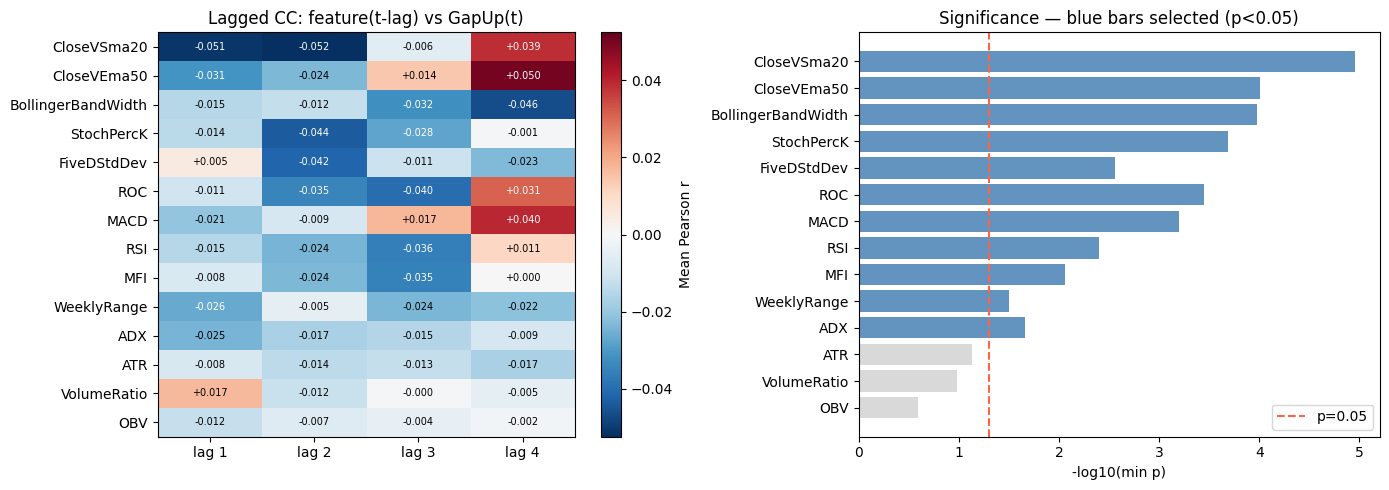

LagCC selected 11/14: ['CloseVSma20', 'CloseVEma50', 'BollingerBandWidth', 'StochPercK', 'FiveDStdDev', 'ROC', 'MACD', 'RSI', 'MFI', 'WeeklyRange', 'ADX']
Dropped       : ['ATR', 'OBV', 'VolumeRatio']


In [ ]:
r_cols = [f'r_lag{l}' for l in LAGS]
r_mat  = lagcc_df[r_cols].values
feats  = lagcc_df.index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

vmax = np.abs(r_mat).max()
im = ax1.imshow(r_mat, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax1.set_xticks(range(len(LAGS))); ax1.set_xticklabels([f'lag {l}' for l in LAGS])
ax1.set_yticks(range(len(feats))); ax1.set_yticklabels(feats)
for i in range(len(feats)):
    for j in range(len(LAGS)):
        ax1.text(j, i, f'{r_mat[i,j]:+.3f}', ha='center', va='center',
                 fontsize=7, color='white' if abs(r_mat[i,j]) > vmax*0.5 else 'black')
plt.colorbar(im, ax=ax1, label='Mean Pearson r')
ax1.set_title('Lagged CC: feature(t-lag) vs GapUp(t)')

neg_log_p = -np.log10(lagcc_df['min_p'].clip(lower=1e-10))
colors    = ['steelblue' if p < 0.05 else 'lightgrey' for p in lagcc_df['min_p']]
ax2.barh(feats, neg_log_p, color=colors, alpha=0.85)
ax2.axvline(-np.log10(0.05), color='tomato', ls='--', lw=1.5, label='p=0.05')
ax2.set_xlabel('-log10(min p)'); ax2.invert_yaxis(); ax2.legend()
ax2.set_title('Significance — blue bars selected (p<0.05)')

plt.tight_layout(); plt.show()

lagcc_features = lagcc_df[lagcc_df['min_p'] < 0.05].index.tolist()
print(f'LagCC selected {len(lagcc_features)}/14: {lagcc_features}')
print(f'Dropped       : {[f for f in FEATURES if f not in lagcc_features]}')

## 13. DW LSTM + LagCC LSTM

Both feature selection methods are run as separate LSTM variants using the same rolling walk-forward setup.

| Variant | Selection criterion | Expected behaviour |
|---|---|---|
| **DW LSTM** | `|DW − 2| > 0.3` — features with meaningful self-autocorrelation | Keeps persistent/mean-reverting signals |
| **LagCC LSTM** | `p < 0.05` one-sample t-test on `corr(f(t-k), GapUp(t))` | Keeps features with direct predictive lag signal |

In [ ]:
X_dw_all, _, _, _ = build_sequences(primary, dw_features,    TARGET, WINDOW)
X_ac_all, _, _, _ = build_sequences(primary, lagcc_features, TARGET, WINDOW)

print(f'DW features ({len(dw_features)}):')
results_dw_df, *_ = run_walkforward(X_dw_all, 'DW')

print(f'\nLagCC features ({len(lagcc_features)}):')
results_ac_df, *_ = run_walkforward(X_ac_all, 'LagCC')

DW features (14):
  [DW] 2019 | h=64 dr=0.3 | AUC=0.569
  [DW] 2020 | h=64 dr=0.3 | AUC=0.540
  [DW] 2021 | h=64 dr=0.3 | AUC=0.534
  [DW] 2022 | h=32 dr=0.2 | AUC=0.543
  [DW] 2023 | h=64 dr=0.2 | AUC=0.564
  [DW] 2024 | h=32 dr=0.3 | AUC=0.542

LagCC features (11):
  [LagCC] 2019 | h=32 dr=0.2 | AUC=0.564
  [LagCC] 2020 | h=32 dr=0.3 | AUC=0.554
  [LagCC] 2021 | h=64 dr=0.2 | AUC=0.576
  [LagCC] 2022 | h=64 dr=0.3 | AUC=0.513
  [LagCC] 2023 | h=64 dr=0.2 | AUC=0.583
  [LagCC] 2024 | h=32 dr=0.2 | AUC=0.570


Avg AUC (non-COVID):
  Original : 0.5480
  DW       : 0.5504  (+0.0024)
  LagCC    : 0.5612  (+0.0132)


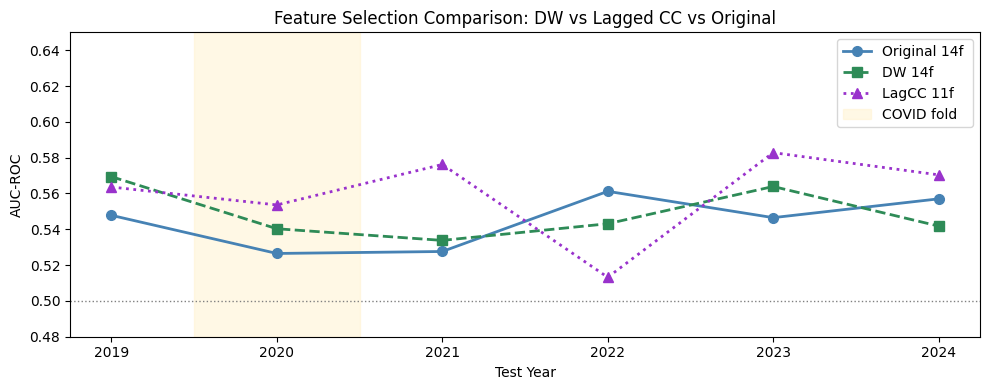

In [136]:
test_yrs = [f['test_year'] for f in FOLDS]

def nc_avg(df):
    return df[df.index != 2020]['AUC-ROC'].mean()

orig_avg = nc_avg(results_df)
dw_avg   = nc_avg(results_dw_df)
ac_avg   = nc_avg(results_ac_df)

print(f'Avg AUC (non-COVID):')
print(f'  Original : {orig_avg:.4f}')
print(f'  DW       : {dw_avg:.4f}  ({dw_avg-orig_avg:+.4f})')
print(f'  LagCC    : {ac_avg:.4f}  ({ac_avg-orig_avg:+.4f})')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test_yrs, results_df['AUC-ROC'],    'o-',  color='steelblue', lw=2, ms=7,
        label=f'Original 14f ')
ax.plot(test_yrs, results_dw_df['AUC-ROC'], 's--', color='seagreen',  lw=2, ms=7,
        label=f'DW {len(dw_features)}f ')
ax.plot(test_yrs, results_ac_df['AUC-ROC'], '^:',  color='darkorchid',lw=2, ms=7,
        label=f'LagCC {len(lagcc_features)}f ')
ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.axvspan(2019.5, 2020.5, color='#fff3cd', alpha=0.5, label='COVID fold')
ax.set_xlabel('Test Year'); ax.set_ylabel('AUC-ROC')
ax.set_title('Feature Selection Comparison: DW vs Lagged CC vs Original')
ax.legend(); ax.set_ylim(0.48, 0.65)
plt.tight_layout(); plt.show()

## 14. LSTM + PCA

PCA is applied at the **feature level**: for each fold, a `StandardScaler` and `PCA(k)` are fitted on the training sequences (all timesteps flattened to N×window rows) and then applied to validation and test sequences. The resulting (N, window, k) tensors replace the original (N, window, 14) tensors as LSTM input.

This is a **per-fold, no-leakage** approach — consistent with the per-fold PCA in `PCA.ipynb`.

**Why PCA might help LSTM:**  
From the Durbin-Watson analysis, all 14 features are strongly autocorrelated, suggesting they may also be mutually correlated (e.g., ATR and BollingerBandWidth both reflect volatility). PCA decorrelates the input, reducing redundancy and potentially easing the LSTM's optimisation landscape.

**k selection:** A sweep over k ∈ {3, 5, 7, 10, 12} is run on the 2019 fold inner validation to find the k that maximises LSTM validation AUC. Cumulative explained variance is also shown as a reference.

  k= 3  inner val AUC=0.6554
  k= 5  inner val AUC=0.6799
  k= 7  inner val AUC=0.6745
  k=10  inner val AUC=0.6620
  k=12  inner val AUC=0.6729

Best k = 5  (inner val AUC=0.6799)


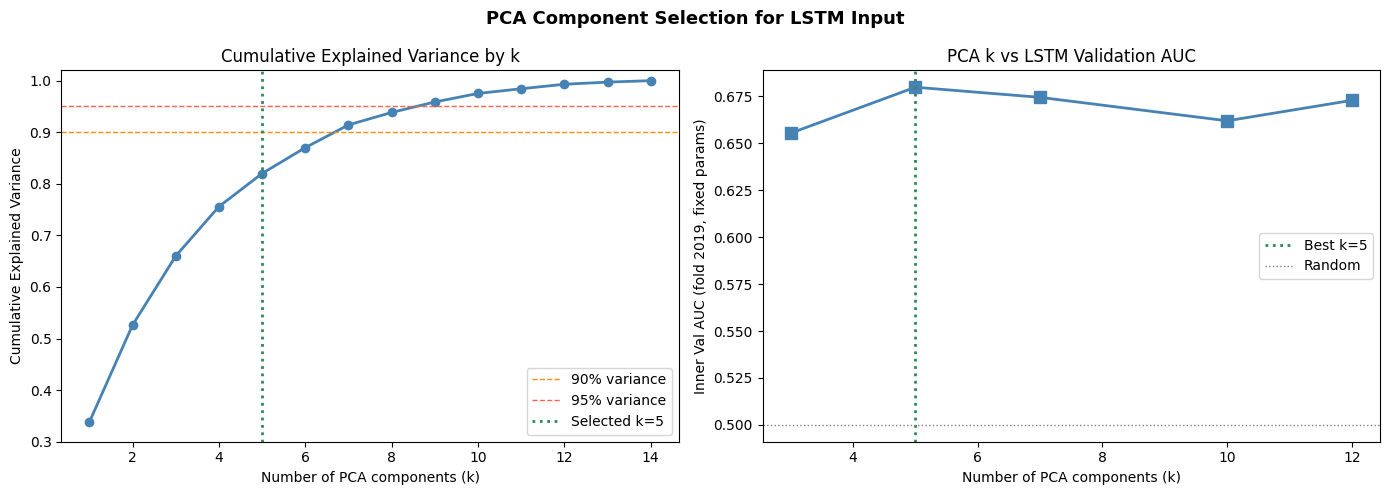

In [ ]:
from sklearn.decomposition import PCA

# k sweep: run LSTM with PCA(k) input on fold-2019 inner validation only.
# Uses fixed params (hidden_size=32, dropout=0.2 — most common across original folds)
# to isolate the effect of k rather than jointly optimising k and architecture.

K_GRID = [3, 5, 7, 10, 12]
SWEEP_PARAMS = {'hidden_size': 32, 'dropout': 0.2}

# Fold 2019 masks (inner split: train 2016-2017, val 2018)
sweep_fold      = FOLDS[0]   # test=2019
sv_train_yrs    = sweep_fold['train_years']
sv_inner_val_yr = max(sv_train_yrs)                              # 2018
sv_inner_trn    = [y for y in sv_train_yrs if y != sv_inner_val_yr]

sv_mask_itrn = np.isin(years_all, sv_inner_trn)
sv_mask_ival  = (years_all == sv_inner_val_yr)

X_sv_itrn_raw = X_all[sv_mask_itrn]; y_sv_itrn = y_all[sv_mask_itrn]
X_sv_ival_raw  = X_all[sv_mask_ival];  y_sv_ival  = y_all[sv_mask_ival]

n_orig_feats = X_sv_itrn_raw.shape[2]  # 14

# Fit scaler + full-rank PCA once (for explained variance plot)
scaler_sv = RobustScaler()
X_sv_itrn_flat = X_sv_itrn_raw.reshape(-1, n_orig_feats)
scaler_sv.fit(X_sv_itrn_flat)
pca_full_sv = PCA(n_components=n_orig_feats, random_state=42)
pca_full_sv.fit(scaler_sv.transform(X_sv_itrn_flat))
cumvar = np.cumsum(pca_full_sv.explained_variance_ratio_)

# k sweep — LSTM inner val AUC
pca_k_aucs = {}
for k in K_GRID:
    pca_k = PCA(n_components=k, random_state=42)
    pca_k.fit(scaler_sv.transform(X_sv_itrn_flat))

    def _apply(X_raw):
        flat_sc = scaler_sv.transform(X_raw.reshape(-1, n_orig_feats))
        return pca_k.transform(flat_sc).reshape(X_raw.shape[0], WINDOW, k).astype(np.float32)

    Xi_k = _apply(X_sv_itrn_raw)
    Xv_k = _apply(X_sv_ival_raw)

    torch.manual_seed(42)
    _, val_auc = fit_model(Xi_k, y_sv_itrn, Xv_k, y_sv_ival, **SWEEP_PARAMS)
    pca_k_aucs[k] = round(val_auc, 4)
    print(f'  k={k:2d}  inner val AUC={val_auc:.4f}')

best_k = max(pca_k_aucs, key=pca_k_aucs.get)
print(f'\nBest k = {best_k}  (inner val AUC={pca_k_aucs[best_k]:.4f})')

# ── Plot: explained variance + k sweep AUC ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, n_orig_feats + 1), cumvar, 'o-', color='steelblue', lw=2, ms=6)
ax1.axhline(0.90, color='darkorange', ls='--', lw=1, label='90% variance')
ax1.axhline(0.95, color='tomato',     ls='--', lw=1, label='95% variance')
ax1.axvline(best_k, color='seagreen', ls=':', lw=2, label=f'Selected k={best_k}')
ax1.set_xlabel('Number of PCA components (k)')
ax1.set_ylabel('Cumulative Explained Variance')
ax1.set_title('Cumulative Explained Variance by k')
ax1.legend(); ax1.set_ylim(0.3, 1.02)

ax2.plot(list(pca_k_aucs.keys()), list(pca_k_aucs.values()),
         's-', color='steelblue', lw=2, ms=8)
ax2.axvline(best_k, color='seagreen', ls=':', lw=2, label=f'Best k={best_k}')
ax2.axhline(0.5, color='grey', ls=':', lw=1, label='Random')
ax2.set_xlabel('Number of PCA components (k)')
ax2.set_ylabel('Inner Val AUC (fold 2019, fixed params)')
ax2.set_title('PCA k vs LSTM Validation AUC')
ax2.legend()

plt.suptitle('PCA Component Selection for LSTM Input', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
fold_results_pca = []
sc_pca = RobustScaler()

for fold in FOLDS:
    test_yr, train_yrs = fold['test_year'], fold['train_years']
    iv_yr  = max(train_yrs)
    it_yrs = [y for y in train_yrs if y != iv_yr]

    mi = np.isin(years_all, it_yrs);  vi = years_all == iv_yr
    mf = np.isin(years_all, train_yrs); mt = years_all == test_yr

    nf = X_all.shape[2]
    sc_pca.fit(X_all[mf].reshape(-1, nf))
    pca = PCA(n_components=best_k, random_state=42).fit(
        sc_pca.transform(X_all[mf].reshape(-1, nf)))

    def prep(X):
        flat = sc_pca.transform(X.reshape(-1, nf))
        return pca.transform(flat).reshape(X.shape[0], WINDOW, best_k).astype(np.float32)

    Xi, Xv, Xf, Xt = prep(X_all[mi]), prep(X_all[vi]), prep(X_all[mf]), prep(X_all[mt])
    yi, yv, yf, yt = y_all[mi], y_all[vi], y_all[mf], y_all[mt]

    best_auc, best_p = -np.inf, None
    for p in PARAM_GRID:
        torch.manual_seed(42)
        _, va = fit_model(Xi, yi, Xv, yv, **p)
        if va > best_auc: best_auc, best_p = va, p.copy()

    torch.manual_seed(42)
    model, _ = fit_model(Xf, yf, Xv, yv, **best_p)
    auc, acc, proba = evaluate(model, Xt, yt)
    preds = (proba >= 0.5).astype(int)
    fold_results_pca.append({
        'Test year': test_yr, 'AUC-ROC': round(auc, 4), 'Accuracy': round(acc, 4),
        'Precision': round(precision_score(yt, preds, zero_division=0), 4),
        'Recall':    round(recall_score(yt, preds,    zero_division=0), 4),
        'F1':        round(f1_score(yt, preds,        zero_division=0), 4),
        'Baseline':  round(max(yt.mean(), 1 - yt.mean()), 4),
    })
    print(f'  [PCA k={best_k}] {test_yr} | h={best_p["hidden_size"]} dr={best_p["dropout"]} | AUC={auc:.3f}')

results_pca_df = pd.DataFrame(fold_results_pca).set_index('Test year')

  [PCA k=5] 2019 | h=64 dr=0.3 | AUC=0.542
  [PCA k=5] 2020 | h=64 dr=0.2 | AUC=0.492
  [PCA k=5] 2021 | h=32 dr=0.3 | AUC=0.530
  [PCA k=5] 2022 | h=64 dr=0.3 | AUC=0.560
  [PCA k=5] 2023 | h=32 dr=0.2 | AUC=0.539
  [PCA k=5] 2024 | h=32 dr=0.2 | AUC=0.516


In [ ]:
results_pca_df = pd.DataFrame(fold_results_pca).set_index('Test year')
non_covid_pca  = results_pca_df[results_pca_df.index != 2020]

display(results_pca_df.style
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
             'F1': '{:.4f}', 'AUC-ROC': '{:.4f}', 'Baseline': '{:.4f}'})
    .highlight_between(subset=pd.IndexSlice[[2020], :], color='#fff3cd'))

print(f'Average metrics — PCA LSTM k={best_k} (excluding COVID fold):')
print(f'  Accuracy:  {non_covid_pca["Accuracy"].mean():.4f}')
print(f'  AUC-ROC:   {non_covid_pca["AUC-ROC"].mean():.4f}')

,AUC-ROC,Accuracy,Precision,Recall,F1,Baseline
Test year,,,,,,
2019,0.5417,0.5464,0.5669,0.5843,0.5755,0.5262
2020,0.4919,0.5090,0.5652,0.5636,0.5644,0.5644
2021,0.5295,0.5125,0.5238,0.5605,0.5415,0.5136
2022,0.5602,0.5115,0.4486,0.8078,0.5769,0.5878
2023,0.5394,0.5393,0.5313,0.4914,0.5106,0.5110
2024,0.5156,0.5050,0.5902,0.4437,0.5065,0.5726


Average metrics — PCA LSTM k=5 (excluding COVID fold):
  Accuracy:  0.5229
  AUC-ROC:   0.5373


## 16. LSTM with Augmented Feature Space

**Motivation:** LSTM with `hidden_size=32` must implicitly learn three things from the raw 14-feature window:
1. Which features matter (signal vs noise)
2. How each feature evolves across the 4 weeks (rate of change)
3. How features interact with each other at each timestep

Explicitly providing higher-dimensional representations reduces the model's learning burden — analogous to feature engineering for tree models, but applied to the LSTM input.

**Two augmentations added:**

| Augmentation | Dimensions added | What it encodes |
|---|---|---|
| **Velocity features** `Δf = f(t) − f(t−1)` | +14 | Rate of change at each timestep — how fast each indicator is moving |
| **Pairwise interactions** | +10 | Products of the top-5 features by permutation importance, computed post-scaling |

**Why velocity for LSTM?** The hidden state can compute differences from consecutive inputs, but must dedicate capacity to learning this. Providing `Δf` explicitly frees hidden units to focus on what-matters-next rather than bookkeeping arithmetic.

**Why interactions post-scaling?** Products of raw features are numerically unstable (OBV in thousands × RSI in 0–100). After StandardScaler brings all features to unit variance, the products are bounded and comparable across indicators.

**Total augmented features: 14 original + 14 velocity + 10 interactions = 38**

In [ ]:
from itertools import combinations as _combos

# ── Velocity features (Δ): computed on the DataFrame pre-fold ──
# For each feature, add the week-over-week difference per ticker.
# The first row of each ticker has no predecessor → fill with 0.
primary_aug = primary.copy()
for feat in FEATURES:
    primary_aug[f'd_{feat}'] = (
        primary_aug.groupby('Ticker')[feat].diff().fillna(0)
    )

VEL_FEATURES = [f'd_{feat}' for feat in FEATURES]
AUG_FEATURES = FEATURES + VEL_FEATURES   # 28 features (before interactions)

# ── Top-5 pairwise interaction indices ──
# Top-5 by permutation importance from original LSTM
TOP5        = ['CloseVSma20', 'MFI', 'StochPercK', 'ROC', 'CloseVEma50']
TOP5_IDX    = [AUG_FEATURES.index(f) for f in TOP5]
INTER_PAIRS = list(_combos(range(len(TOP5)), 2))   # 10 pairs
INTER_NAMES = [f'{TOP5[i]}×{TOP5[j]}' for i, j in INTER_PAIRS]
ALL_FEATURES = AUG_FEATURES + INTER_NAMES          # 38 features

def add_interactions(X_scaled):
    """
    Appends pairwise products of top-5 features (post-scaling) to the input.
    X_scaled: (N, window, 28)  →  returns (N, window, 38)
    """
    top5_vals = X_scaled[:, :, TOP5_IDX]           # (N, window, 5)
    new_feats = [
        (top5_vals[:, :, i] * top5_vals[:, :, j])[:, :, np.newaxis]
        for i, j in INTER_PAIRS
    ]
    return np.concatenate([X_scaled] + new_feats, axis=2).astype(np.float32)

# Build sequences with velocity features (interactions added per-fold after scaling)
X_aug_all, _, _, _ = build_sequences(primary_aug, AUG_FEATURES, TARGET, WINDOW)

print(f'Original feature count:   {len(FEATURES)}')
print(f'+ Velocity features:      {len(VEL_FEATURES)}')
print(f'+ Pairwise interactions:  {len(INTER_NAMES)}')
print(f'= Augmented total:        {len(ALL_FEATURES)}')
print(f'Sequence shape:           {X_aug_all.shape}  (before interactions)')
print()
print('Velocity features (first 5):', VEL_FEATURES[:5])
print('Interactions:', INTER_NAMES)

Original feature count:   14
+ Velocity features:      14
+ Pairwise interactions:  10
= Augmented total:        38
Sequence shape:           (8071, 4, 28)  (before interactions)

Velocity features (first 5): ['d_RSI', 'd_MACD', 'd_ROC', 'd_StochPercK', 'd_CloseVEma50']
Interactions: ['CloseVSma20×MFI', 'CloseVSma20×StochPercK', 'CloseVSma20×ROC', 'CloseVSma20×CloseVEma50', 'MFI×StochPercK', 'MFI×ROC', 'MFI×CloseVEma50', 'StochPercK×ROC', 'StochPercK×CloseVEma50', 'ROC×CloseVEma50']


In [ ]:
print(f'Augmented LSTM (38 features = 14 orig + 14 velocity + 10 interactions):')
results_aug_df, *_ = run_walkforward(X_aug_all, 'Augmented', transform=add_interactions)

Augmented LSTM (38 features = 14 orig + 14 velocity + 10 interactions):
  [Augmented] 2019 | h=32 dr=0.2 | AUC=0.556
  [Augmented] 2020 | h=64 dr=0.2 | AUC=0.549
  [Augmented] 2021 | h=32 dr=0.2 | AUC=0.586
  [Augmented] 2022 | h=32 dr=0.2 | AUC=0.542
  [Augmented] 2023 | h=64 dr=0.2 | AUC=0.551
  [Augmented] 2024 | h=32 dr=0.3 | AUC=0.531


## 17. LSTM + Augmented Feature Space + Lagged CC

**Motivation:** The augmented feature space (28 features: 14 original + 14 velocity) may contain redundant velocity features that add noise. Applying lagged cross-correlation selection on the augmented space keeps only velocity features that are genuinely predictive of `GapUp(t)`.

**Pipeline:**
1. Build velocity features: Δf = f(t) − f(t-1) per ticker → 28 features  
2. Apply lagged cross-correlation (lags 1–4) across tickers; keep features with p < 0.05  
3. Train LSTM on selected augmented features (no interactions — CC selection already prunes)

In [ ]:
from scipy import stats as scipy_stats

# Lagged cross-correlation on the augmented feature space (28 features)
AUG_LAGS = list(range(1, WINDOW + 1))

aug_lag_cors = {feat: {lag: [] for lag in AUG_LAGS} for feat in AUG_FEATURES}

for ticker, grp in primary_aug.sort_values(['Ticker', 'Date']).groupby('Ticker'):
    grp = grp.reset_index(drop=True)
    if len(grp) < 20:
        continue
    for feat in AUG_FEATURES:
        for lag in AUG_LAGS:
            x    = grp[feat].shift(lag)
            y    = grp[TARGET]
            mask = x.notna()
            xv, yv = x[mask].values, y[mask].values
            if len(xv) < 10:
                continue
            r, _ = scipy_stats.pearsonr(xv, yv)
            aug_lag_cors[feat][lag].append(r)

aug_lag_rows = []
for feat in AUG_FEATURES:
    row = {'feature': feat}
    for lag in AUG_LAGS:
        cors = aug_lag_cors[feat][lag]
        if len(cors) >= 3:
            t, p = scipy_stats.ttest_1samp(cors, 0)
            row[f'r_lag{lag}'] = np.mean(cors)
            row[f'p_lag{lag}'] = p
        else:
            row[f'r_lag{lag}'] = 0.0
            row[f'p_lag{lag}'] = 1.0
    row['max_abs_r'] = max(abs(row[f'r_lag{l}']) for l in AUG_LAGS)
    row['min_p']     = min(row[f'p_lag{l}'] for l in AUG_LAGS)
    aug_lag_rows.append(row)

aug_lagcc_df = pd.DataFrame(aug_lag_rows).set_index('feature').sort_values('max_abs_r', ascending=False)

# Select features with at least one lag where p < 0.05
aug_ac_features = [f for f in AUG_FEATURES if aug_lagcc_df.loc[f, 'min_p'] < 0.05]
aug_dropped     = [f for f in AUG_FEATURES if f not in aug_ac_features]

print(f'Augmented Lagged CC Feature Selection')
print(f'  Total augmented features : {len(AUG_FEATURES)} (14 original + 14 velocity)')
print(f'  Selected (p<0.05)        : {len(aug_ac_features)}')
print(f'  Dropped                  : {len(aug_dropped)}')
print()
print(f'Dropped: {aug_dropped}')
print()
print(f'{"Feature":28s}  {"lag1":>8s} {"lag2":>8s} {"lag3":>8s} {"lag4":>8s}  {"max|r|":>7s}  {"min_p":>8s}')
print('-' * 90)
for feat, row in aug_lagcc_df.iterrows():
    r1,r2,r3,r4 = row['r_lag1'],row['r_lag2'],row['r_lag3'],row['r_lag4']
    mr, mp = row['max_abs_r'], row['min_p']
    sig = ' *' if mp < 0.05 else '  '
    print(f'{feat:28s}  {r1:+8.4f} {r2:+8.4f} {r3:+8.4f} {r4:+8.4f}  {mr:7.4f}  {mp:8.4f}{sig}')

Augmented Lagged CC Feature Selection
  Total augmented features : 28 (14 original + 14 velocity)
  Selected (p<0.05)        : 22
  Dropped                  : 6

Dropped: ['ATR', 'OBV', 'VolumeRatio', 'd_ADX', 'd_ATR', 'd_WeeklyRange']

Feature                           lag1     lag2     lag3     lag4   max|r|     min_p
------------------------------------------------------------------------------------------
CloseVSma20                    -0.0508  -0.0524  -0.0057  +0.0388   0.0524    0.0000 *
CloseVEma50                    -0.0314  -0.0236  +0.0141  +0.0501   0.0501    0.0001 *
d_ROC                          +0.0166  +0.0043  -0.0491  +0.0036   0.0491    0.0000 *
d_CloseVEma50                  -0.0089  -0.0482  -0.0488  +0.0081   0.0488    0.0000 *
d_OBV                          -0.0285  -0.0485  -0.0134  +0.0050   0.0485    0.0001 *
d_BollingerBandWidth           -0.0022  +0.0210  +0.0189  -0.0470   0.0470    0.0007 *
BollingerBandWidth             -0.0149  -0.0124  -0.0319  -0.0465

In [ ]:
print(f'Aug+LagCC LSTM ({len(aug_ac_features)} features):')
results_augac_df, *_ = run_walkforward(X_augac_all, 'Aug+LagCC')

Aug+LagCC LSTM (22 features):
  [Aug+LagCC] 2019 | h=64 dr=0.2 | AUC=0.558
  [Aug+LagCC] 2020 | h=64 dr=0.2 | AUC=0.538
  [Aug+LagCC] 2021 | h=32 dr=0.3 | AUC=0.572
  [Aug+LagCC] 2022 | h=32 dr=0.3 | AUC=0.536
  [Aug+LagCC] 2023 | h=64 dr=0.3 | AUC=0.575
  [Aug+LagCC] 2024 | h=32 dr=0.2 | AUC=0.533


## 15. Final Comparison — All LSTM Variants

| Variant | Features | Key idea |
|---|---|---|
| **Original** | 14 | All technical indicators |
| **DW** | varies | Self-autocorrelated features only |
| **LagCC** | ~11 | Features with direct predictive lag signal |
| **PCA** | k components | Orthogonal projections of original 14 |
| **Augmented** | 38 | Original + velocity (Δ) + top-5 interactions |
| **Aug+LagCC** | varies | Augmented space filtered by lagged CC |

Variant                 Feats      AUC     ΔAUC      Acc     ΔAcc
-----------------------------------------------------------------
Original                   14   0.5480  +0.0000   0.5249  +0.0000
DW                         14   0.5504  +0.0024   0.5310  +0.0061
LagCC                      11   0.5612  +0.0132   0.5411  +0.0162
PCA k=5                     5   0.5373  -0.0107   0.5229  -0.0020
Augmented                  38   0.5531  +0.0051   0.5343  +0.0094
Aug+LagCC                  22   0.5549  +0.0069   0.5298  +0.0049


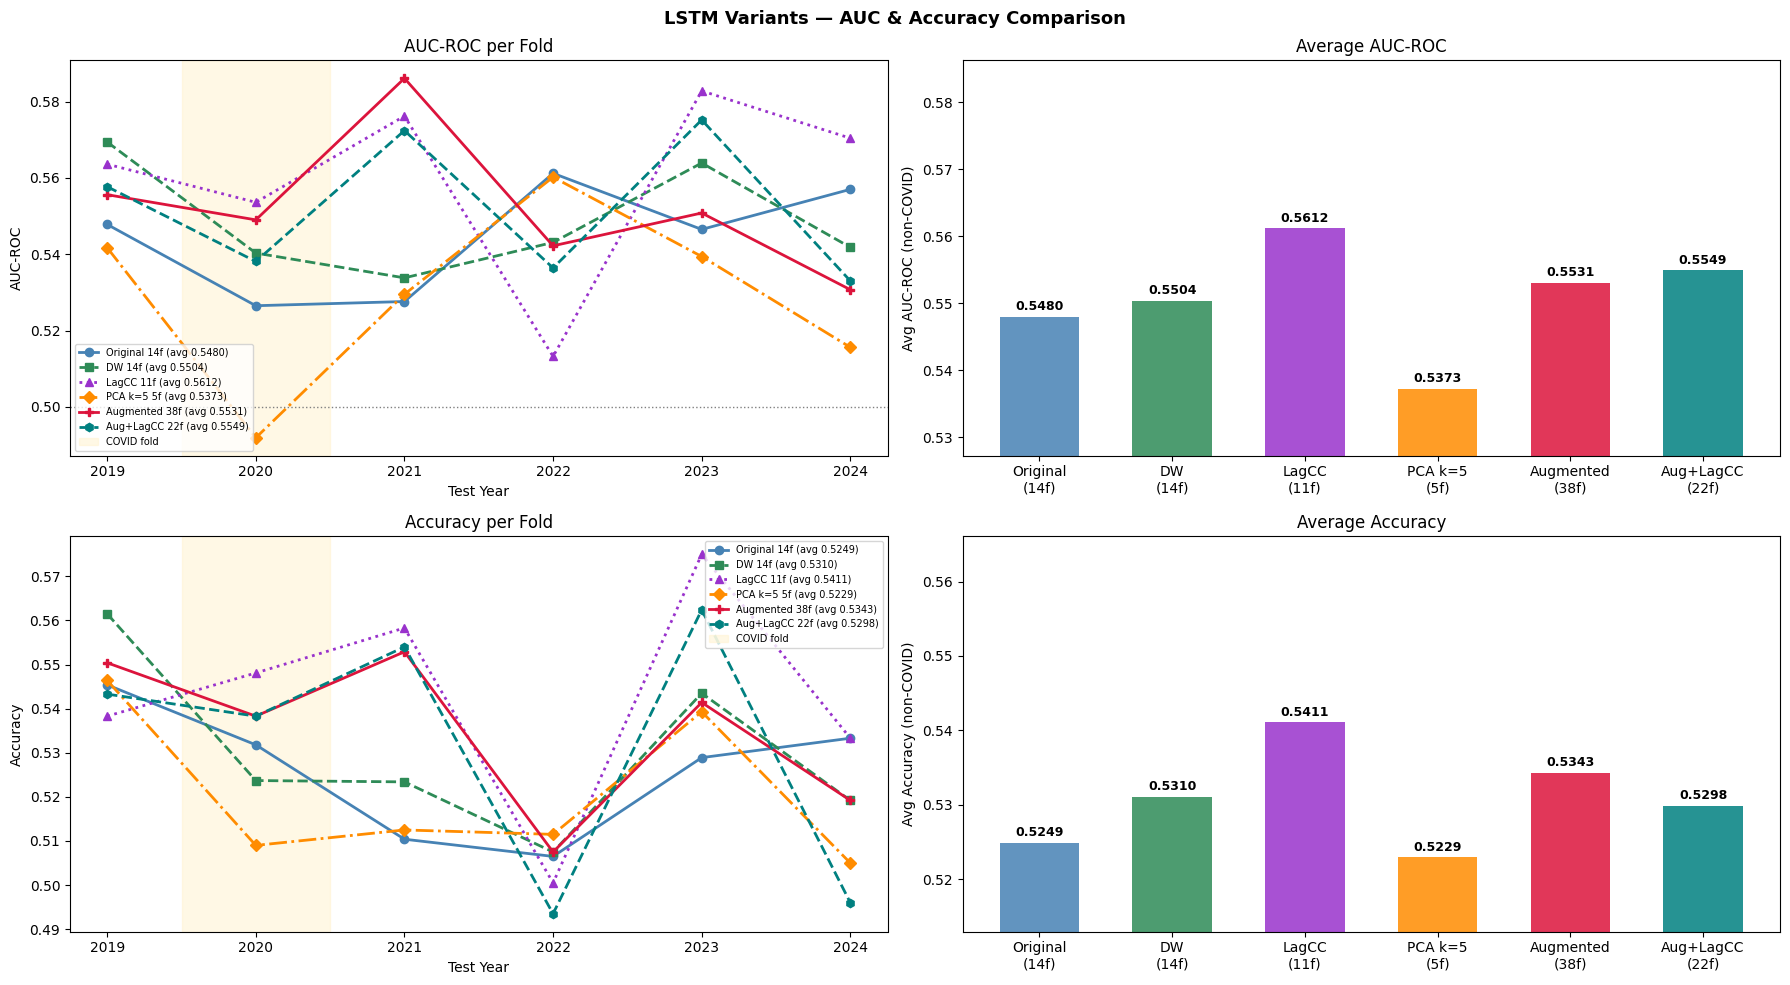

,Original (14f),DW (14f),LagCC (11f),PCA k=5 (5f),Augmented (38f),Aug+LagCC (22f)
Test year,,,,,,
2019,0.5478,0.5694,0.5636,0.5417,0.5556,0.5577
2020,0.5265,0.5403,0.5536,0.4919,0.5490,0.5381
2021,0.5276,0.5338,0.5762,0.5295,0.5861,0.5724
2022,0.5612,0.5431,0.5132,0.5602,0.5422,0.5364
2023,0.5465,0.5639,0.5828,0.5394,0.5508,0.5752
2024,0.5570,0.5418,0.5704,0.5156,0.5307,0.5330


In [ ]:
test_yrs = [f['test_year'] for f in FOLDS]

VARIANTS = [
    ('Original',              results_df,      14,                   'steelblue',  'o',  '-'),
    (f'DW',                   results_dw_df,   len(dw_features),     'seagreen',   's',  '--'),
    (f'LagCC',                results_ac_df,   len(lagcc_features),  'darkorchid', '^',  ':'),
    (f'PCA k={best_k}',       results_pca_df,  best_k,               'darkorange', 'D',  '-.'),
    ('Augmented',             results_aug_df,  38,                   'crimson',    'P',  '-'),
    (f'Aug+LagCC',            results_augac_df,len(aug_ac_features), 'teal',       'h',  '--'),
]

def nc_avg(df, col='AUC-ROC'):
    return df[df.index != 2020][col].mean()

print(f'{"Variant":<22s}  {"Feats":>5s}  {"AUC":>7s}  {"ΔAUC":>7s}  {"Acc":>7s}  {"ΔAcc":>7s}')
print('-' * 65)
orig_auc_avg = nc_avg(results_df)
orig_acc_avg = nc_avg(results_df, 'Accuracy')
for name, df, nf, *_ in VARIANTS:
    auc_v = nc_avg(df); acc_v = nc_avg(df, 'Accuracy')
    print(f'{name:<22s}  {nf:5d}  {auc_v:7.4f}  {auc_v-orig_auc_avg:+7.4f}  {acc_v:7.4f}  {acc_v-orig_acc_avg:+7.4f}')

# ── 2x2 chart ──
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for metric, row_idx in [('AUC-ROC', 0), ('Accuracy', 1)]:
    # Per-fold line chart
    ax = axes[row_idx, 0]
    for name, df, nf, color, mk, ls in VARIANTS:
        avg_v = nc_avg(df, metric)
        ax.plot(test_yrs, df[metric].values, marker=mk, ls=ls, color=color,
                lw=2, ms=6, label=f'{name} {nf}f (avg {avg_v:.4f})')
    if metric == 'AUC-ROC':
        ax.axhline(0.5, color='grey', ls=':', lw=1)
    ax.axvspan(2019.5, 2020.5, color='#fff3cd', alpha=0.5, label='COVID fold')
    ax.set_xlabel('Test Year'); ax.set_ylabel(metric)
    ax.set_title(f'{metric} per Fold'); ax.legend(fontsize=7)

    # Average bar chart
    ax = axes[row_idx, 1]
    labels = [f'{n}\n({nf}f)' for n, _, nf, *_ in VARIANTS]
    avgs   = [nc_avg(df, metric) for _, df, *_ in VARIANTS]
    colors = [c for *_, c, mk, ls in VARIANTS]
    bars   = ax.bar(labels, avgs, color=colors, alpha=0.85, width=0.6)
    if metric == 'AUC-ROC':
        ax.axhline(0.5, color='grey', ls=':', lw=1)
    for bar, val in zip(bars, avgs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylabel(f'Avg {metric} (non-COVID)')
    ax.set_title(f'Average {metric}')
    ax.set_ylim(min(avgs) - 0.01, max(avgs) + 0.025)

plt.suptitle('LSTM Variants — AUC & Accuracy Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Per-fold table ──
cmp = pd.DataFrame({
    f'{name} ({nf}f)': df['AUC-ROC'] for name, df, nf, *_ in VARIANTS
})
display(cmp.style
    .format('{:.4f}')
    .highlight_max(axis=1, color='#d4edda')
    .highlight_between(subset=pd.IndexSlice[[2020], :], color='#fff3cd'))